In [76]:
import os
import functools
import operator
import warnings
warnings.filterwarnings('ignore')


# Typing Decorators
from typing import List, Dict
from IPython.display import display, Markdown
from typing_extensions import TypedDict, Annotated


# Standard ML Libraries
import pandas as pd
import numpy as np
from PIL import Image

# Huggingface Models
from datasets import load_dataset
from transformers import Pipeline
from transformers import (AutoModelForImageClassification, 
                            AutoImageProcessor)

#langchain libraries
from langchain_core.messages import BaseMessage, AIMessage
from langchain_core.prompts import PromptTemplate

# langgraph libraries
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END

# Load custom defined packages
from models import (GenderPredictionFromPreTrainedModel, 
                    AgePredictionForPretrainedModel)

### 1. Front Desk Verification

In [77]:
# Load patient dataset
updated_patient_df = pd.read_csv('datasets/input/processed/updated_patient_df.csv')
updated_patient_df.drop('Unnamed: 0', axis = 1, inplace = True)
updated_patient_df.head(10)


# Pick a Random Patient: A female between 20 and 29 and with Pneumonia as Positive 
selected_patients = updated_patient_df[
    (updated_patient_df['Gender'] == 'Female') & \
        (updated_patient_df['Age'].between(20, 29)) & \
            (updated_patient_df['Difficulty Breathing'] == 'Yes') & \
                (updated_patient_df['Outcome Variable'] == 'Positive')]

# Choosing first patient details as our subject
selected_patients = (selected_patients
                                .reset_index(drop = True)
                                .iloc[0, :])

selected_patients


Disease                     Influenza
Fever                             Yes
Cough                             Yes
Fatigue                           Yes
Difficulty Breathing              Yes
Age                                25
Gender                         Female
Blood Pressure                 Normal
Cholesterol Level              Normal
Outcome Variable             Positive
First_Name                     Amrita
Last_Name                        Nair
Patient_ID              PAT1000000007
Full_Name                 Amrita_Nair
Name: 0, dtype: object

In [78]:
def patient_verification_tool(image_path, updated_patient_df, selected_patient_data):
    from PIL import Image
    # Gender Prediction
    image = Image.open(image_path)

    # Load PreTrained Model - Gender
    gender_processor = AutoImageProcessor.from_pretrained("rizvandwiki/gender-classification")
    gender_model = AutoModelForImageClassification.from_pretrained("rizvandwiki/gender-classification")

    # Generate Gender Classification Predictions 
    predicted_gender = GenderPredictionFromPreTrainedModel(image, gender_processor, gender_model)

    # Load PreTrained Model - Age Group Prediction
    age_processor = AutoImageProcessor.from_pretrained("nateraw/vit-age-classifier")
    age_model = AutoModelForImageClassification.from_pretrained("nateraw/vit-age-classifier")

    # Generate Image Classification Predictions
    predicted_age_group = AgePredictionForPretrainedModel(image, age_processor, age_model)


    # Parse the age range string (e.g .. 20-29)
    age_min, age_max = map(int, predicted_age_group.split('-'))
    print(f"Age Group Prediction: Minimum : {age_min} and Maximum: {age_max}")

    # Now, we have to check if the respective age group of the customer and gender 
    # is matching to what we have predicted using the pretrained model
    updated_patient_df['Gender'] = updated_patient_df['Gender'].apply(lambda x : x.lower())
    matching_records = updated_patient_df[
                (updated_patient_df["First_Name"]== selected_patient_data["First_Name"]) &
                (updated_patient_df["Last_Name"] == selected_patient_data["Last_Name"]) &
                (updated_patient_df["Patient_ID"] == selected_patient_data["Patient_ID"]) &
                (updated_patient_df["Gender"] == predicted_gender) &
                (updated_patient_df["Age"].between(age_min, age_max))
    ]

    if matching_records.empty:
        patient_verification = "Patient ID is not verified"
    else:
        patient_verification = f"""Verification successfull.
                                Patient is: {selected_patient_data["First_Name"]} {selected_patient_data["Last_Name"]}
                                with ID : {selected_patient_data["Patient_ID"]} 
                                which is {predicted_gender} in age group of {predicted_age_group} can proceed to the physician
        """

    return patient_verification


front_desk_verification_status = patient_verification_tool(
    image_path = 'datasets/FaceID/image1.png', 
    updated_patient_df = updated_patient_df, 
    selected_patient_data = selected_patients
)

display(Markdown(front_desk_verification_status))

[transformers] loading configuration file preprocessor_config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--rizvandwiki--gender-classification/snapshots/380b17658cc037b246aab0b62a20deb7dd607e65/preprocessor_config.json
[transformers] loading configuration file preprocessor_config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--rizvandwiki--gender-classification/snapshots/380b17658cc037b246aab0b62a20deb7dd607e65/preprocessor_config.json
[transformers] Image processor ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

[transformers] loading configuration file config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--rizva

Gender Prediction using Pre-Trained Model : female


[transformers] loading configuration file config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--nateraw--vit-age-classifier/snapshots/4b5acc345d9692c3ff4f45d250531afd3a3da0ef/config.json
[transformers] Model config ViTConfig {
  "architectures": [
    "ViTForImageClassification"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "id2label": {
    "0": "0-2",
    "1": "3-9",
    "2": "10-19",
    "3": "20-29",
    "4": "30-39",
    "5": "40-49",
    "6": "50-59",
    "7": "60-69",
    "8": "more than 70"
  },
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "0-2": 0,
    "10-19": 2,
    "20-29": 3,
    "3-9": 1,
    "30-39": 4,
    "40-49": 5,
    "50-59": 6,
    "60-69": 7,
    "more than 70": 8
  },
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_lay

Age Prediction to the Class: 20-29
Age Group Prediction: Minimum : 20 and Maximum: 29


Verification successfull.
                                Patient is: Amrita Nair
                                with ID : PAT1000000007 
                                which is female in age group of 20-29 can proceed to the physician
        

## 2. Physician Agent

#### 2.1 Questioning Patient

In [79]:
def question_patient(selected_patients: Dict)->str:

    # We are gonna replicate the real world situation
    # Now that we are gonna ask the patient about the symptoms, generating the response 
    # and then summarizing the response based on the patient data

    symptom_questions = {
        'Cough' : "\nAre you having any cough?\n", 
        'Fatigue': "\nAre you having any Fatigue?\n", 
        'Difficulty Breathing': "\nAre you experiencing any difficulty while breathing?\n"
    }

    # We are gonna append the question and response given by the patient
    conversations = []

    for symptom, question in symptom_questions.items():
        conversations.append(f"\nPhysician: {question}")
        response = selected_patients.get(symptom, "No")
        answer = "Yes" if response == "Yes" else "No"
        conversations.append(f"\nPatient: {answer}")

    # Now, we got the response from the patient we are gonna retrieve the patient information
    first_name = selected_patients.get('First_Name', "No Info")
    last_name = selected_patients.get('Last_Name', 'No Info')
    patient_id = selected_patients.get('Patient_ID', 'No Info')
    patient_gender = selected_patients.get('Gender', 'No Info')
    patient_age = selected_patients.get('Age', 'No Info')

    # We got the patient information and now our physician gonna summarize the information that
    # patient said till now 
    profile = f"\nYou are {first_name} {last_name}, a {patient_age} years old {patient_gender} with Patient ID : {patient_id}."
    summary = profile + "\nI gathered that the you are experiencing the following:\n"
    summaries = []
    for symptom in symptom_questions.keys():
        response = selected_patients.get(symptom, "No")
        if response == 'Yes':
            summaries.append(f'You are experiencing {symptom.lower()}')
        else:
            summaries.append(f"I'm glad you are not experienncing any {symptom.lower()}")

    # Creating the summary that physician is gonna speak
    summaries = ' ; '.join(summaries)+"." 
    summary += summaries 

    conversations.append(f"\nPhysician summarizing the conversation: {summary}")
    conversations = '\n'.join(conversations) # Concatenating the conversations 
    
    return conversations

display(Markdown(question_patient(selected_patients)))


Physician: 
Are you having any cough?


Patient: Yes

Physician: 
Are you having any Fatigue?


Patient: Yes

Physician: 
Are you experiencing any difficulty while breathing?


Patient: Yes

Physician summarizing the conversation: 
You are Amrita Nair, a 25 years old Female with Patient ID : PAT1000000007.
I gathered that the you are experiencing the following:
You are experiencing cough ; You are experiencing fatigue ; You are experiencing difficulty breathing.

#### 2.2 Perform Examination

In [80]:
def perform_examination(selected_patients:Dict)-> str:
    "Performs Examination by reporting fever, blood pressure and body Cholesterol Level from patient data"
    fever = selected_patients.get('Fever', 'Unknown')
    blood_pressure = selected_patients.get('Blood Pressure', "Unknown")
    cholesterol_level = selected_patients.get('Cholesterol Level', "Unknown")

    return f"Examination Results: Fever : {fever}, Blood Pressure: {blood_pressure} and Cholesterol level: {cholesterol_level}"

display(Markdown(perform_examination(selected_patients)))

Examination Results: Fever : Yes, Blood Pressure: Normal and Cholesterol level: Normal

#### 2.3 Diagnois Patient

In [81]:
def diagnois_patient(selected_patients:Dict)->str:
    "Provides diagnosis based on Disease and Outcome columns in patient data"
    disease = selected_patients.get('Disease', "Unknown")
    outcome = selected_patients.get('Outcome Variable', "Unknown")

    if outcome == 'Yes':
        diagnosis = "Make X-ray for Chest"
    else:
        diagnosis = "Rest to Recover"

    return f"Disease : {disease} Outcome Variable : {outcome} and Final diagnois: {diagnosis}", diagnosis


diagnois_patient(selected_patients)

('Disease : Influenza Outcome Variable : Positive and Final diagnois: Rest to Recover',
 'Rest to Recover')

## 3. Radiologist Agent

In [82]:
def examine_Xray(patient_x_ray_path, pretrained_model_name_or_path) -> str:

    # load the image from the huggingface 
    dataset = load_dataset('imagefolder', 
                    data_dir = patient_x_ray_path)

    # Randomly choose the image 
    randomInt= np.random.randint(0, len(dataset["train"]))
    randomImg= dataset["train"][randomInt]['image'] # randomly choosen image 
    print(f'Randomly choosen image : {randomInt}')


    processor = AutoImageProcessor.from_pretrained(pretrained_model_name_or_path = pretrained_model_name_or_path)
    model = AutoModelForImageClassification.from_pretrained(pretrained_model_name_or_path = pretrained_model_name_or_path)

    inputs = processor(images = randomImg, return_tensors = 'pt')

    # Generate predictions
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = logits.argmax(-1).item()

    # Map the prediction to the class
    classes = model.config.id2label 
    pneumonia_class = classes[predicted_class]

    return pneumonia_class

examine_Xray(
    patient_x_ray_path= 'datasets/input/chest_xray',
    pretrained_model_name_or_path= 'lxyuan/vit-xray-pneumonia-classification'
)

[transformers] loading configuration file preprocessor_config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--lxyuan--vit-xray-pneumonia-classification/snapshots/2187224687021e1dac2d850bb18e40b8a6f7bf7b/preprocessor_config.json


Randomly choosen image : 1119


[transformers] loading configuration file preprocessor_config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--lxyuan--vit-xray-pneumonia-classification/snapshots/2187224687021e1dac2d850bb18e40b8a6f7bf7b/preprocessor_config.json
[transformers] Image processor ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

[transformers] loading configuration file config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--lxyuan--vit-xray-pneumonia-classification/snapshots/2187224687021e1dac2d850bb18e40b8a6f7bf7b/config.json
[transformers] Model config ViTConfig {
  "architectures": [
    "ViTForImageClassification"
  ],
  "attention_probs_dropout_prob": 0.0,
  "d

'NORMAL'

# 1. Define StateGraph

In [83]:
class AgentState(TypedDict):
    initial_prompt : str
    messages : Annotated[List[BaseMessage], operator.add]
    
    # patient identification
    patient_verification : str

    # Radiologist Prediction
    prediction : str

    # Physician Agent
    question_patient : str
    examination_patient : str
    diagnosis_patient : str
    diagnosis : str

# 2. Define Agent Nodes

In [84]:
def front_desk_agent(state,
                        image_path: str, 
                        selected_patient_data:pd.DataFrame, 
                        updated_patient_df:pd.DataFrame):
    
    initial_prompt = state["initial_prompt"]
    # Call the Patient Verification Tool
    patient_verification = patient_verification_tool(
        image_path = image_path, 
        updated_patient_df = updated_patient_df, 
        selected_patient_data = selected_patient_data
    )

    return {'patient_verification':patient_verification}


front_desk_agent_node = functools.partial(front_desk_agent, 
                                    image_path = 'datasets/FaceID/image1.png', 
                                    updated_patient_df = updated_patient_df, 
                                    selected_patient_data = selected_patients)

In [85]:
def physician_agent_function(state, selected_patients):
    question_patients = question_patient(selected_patients)
    examination_patient = perform_examination(selected_patients)
    diagnosis_patient, diagnosis = diagnois_patient(selected_patients)

    return {'question_patient':question_patients, 
            'examination_patient':examination_patient, 
            'diagnosis_patient': diagnosis_patient, 
            'diagnosis':diagnosis}


# we have to use the functools while agent node takes any input
physician_agent_node = functools.partial(physician_agent_function, 
                                            selected_patients = selected_patients)

In [86]:
def radiologistNode(state, patient_x_ray_path, pretrained_model_name_or_path):
    prediction = examine_Xray(
        patient_x_ray_path= patient_x_ray_path,
        pretrained_model_name_or_path= pretrained_model_name_or_path
    )

    return {'prediction': prediction}

radiologist_agent_node = functools.partial(
    radiologistNode, 
    patient_x_ray_path = 'datasets/input/chest_xray', 
    pretrained_model_name_or_path = 'lxyuan/vit-xray-pneumonia-classification'
)

In [87]:
def decide_on_radialogist(state):
    if state["diagnosis"] == "Make X-ray for Chest":
        return "radialogist_node"
    else:
        return "end"

# 3. Define Workflow

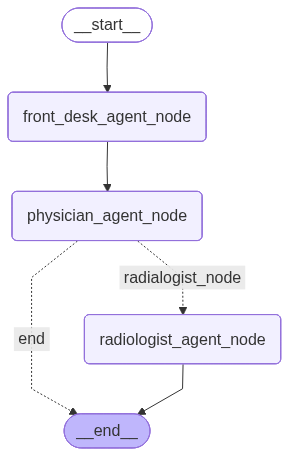

In [88]:
graph = StateGraph(AgentState)

# add nodes 
graph.add_node("front_desk_agent_node", front_desk_agent_node)
graph.add_node("physician_agent_node",physician_agent_node)
graph.add_node("radiologist_agent_node", radiologist_agent_node)

# add edges
graph.add_edge(START, "front_desk_agent_node")
graph.add_edge("front_desk_agent_node", "physician_agent_node")
graph.add_conditional_edges("physician_agent_node", 
                                decide_on_radialogist, 
                                {'radialogist_node' : 'radiologist_agent_node',
                                    'end': END}
                            )
graph.add_edge("radiologist_agent_node", END)

# compile graph
hospital_workflow = graph.compile()
hospital_workflow

In [89]:
inputs = {
    'initial_prompt' : "Start with the following Patient" 
}

hospital_workflow.invoke(inputs)

[transformers] loading configuration file preprocessor_config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--rizvandwiki--gender-classification/snapshots/380b17658cc037b246aab0b62a20deb7dd607e65/preprocessor_config.json
[transformers] loading configuration file preprocessor_config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--rizvandwiki--gender-classification/snapshots/380b17658cc037b246aab0b62a20deb7dd607e65/preprocessor_config.json
[transformers] Image processor ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

[transformers] loading configuration file config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--rizva

Gender Prediction using Pre-Trained Model : female


[transformers] loading configuration file preprocessor_config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--nateraw--vit-age-classifier/snapshots/4b5acc345d9692c3ff4f45d250531afd3a3da0ef/preprocessor_config.json
[transformers] loading configuration file config.json from cache at /Users/kavisanthoshkumar/.cache/huggingface/hub/models--nateraw--vit-age-classifier/snapshots/4b5acc345d9692c3ff4f45d250531afd3a3da0ef/config.json
[transformers] Model config ViTConfig {
  "architectures": [
    "ViTForImageClassification"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "id2label": {
    "0": "0-2",
    "1": "3-9",
    "2": "10-19",
    "3": "20-29",
    "4": "30-39",
    "5": "40-49",
    "6": "50-59",
    "7": "60-69",
    "8": "more than 70"
  },
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "0-2": 0,
    "10-19": 

Age Prediction to the Class: 20-29
Age Group Prediction: Minimum : 20 and Maximum: 29


{'initial_prompt': 'Start with the following Patient',
 'messages': [],
 'patient_verification': 'Verification successfull.\n                                Patient is: Amrita Nair\n                                with ID : PAT1000000007 \n                                which is female in age group of 20-29 can proceed to the physician\n        ',
 'question_patient': '\nPhysician: \nAre you having any cough?\n\n\nPatient: Yes\n\nPhysician: \nAre you having any Fatigue?\n\n\nPatient: Yes\n\nPhysician: \nAre you experiencing any difficulty while breathing?\n\n\nPatient: Yes\n\nPhysician summarizing the conversation: \nYou are Amrita Nair, a 25 years old Female with Patient ID : PAT1000000007.\nI gathered that the you are experiencing the following:\nYou are experiencing cough ; You are experiencing fatigue ; You are experiencing difficulty breathing.',
 'examination_patient': 'Examination Results: Fever : Yes, Blood Pressure: Normal and Cholesterol level: Normal',
 'diagnosis_patient':